# set environment

In [16]:
### Basic
import numpy  as np
import scipy  as sc
import pandas as pd
import glob, os, re
import pickle, sys

### import flowImg
py_path = "/local_data/notebooks/clintko/GitRepo/Proj_Flow2Image"
sys.path.insert(0, py_path)
from flowImg import *

### plot
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-whitegrid')

### directory
DAT_DIR = "/data/clintko/flow_EQAPOL_normal/mpsk"

In [3]:
ls /data/clintko/flow_EQAPOL_normal/mpsk

C_1e4.csv                mpsk_1e4_costim_chain.RDS  mpsk_1e4_simulation.P
mpsk_1e4_cmv_cal.RDS     mpsk_1e4_costim_res.RDS    Y_1e4_cmv.csv
mpsk_1e4_cmv_chain.RDS   mpsk_1e4_seb_cal.RDS       Y_1e4_costim.csv
mpsk_1e4_cmv_res.RDS     mpsk_1e4_seb_chain.RDS     Y_1e4_seb.csv
mpsk_1e4_costim_cal.RDS  mpsk_1e4_seb_res.RDS


# Load data

In [5]:
fpath  = os.path.join(DAT_DIR, "mpsk_1e4_simulation.P")
file   = open(fpath, "rb")
data   = pickle.load(file)
label  = data["label"]
matrix = data["matrix"]

check dimension of the data

In [6]:
print(label.shape)
print(matrix.shape)

(330,)
(330, 10000, 14)


# Wrap the data

In [7]:
wrap_data = Data_Wrapper(matrix, label)
print(wrap_data)

Label: Counter({0: 110, 1: 110, 2: 110})
    0: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109]
    1: [110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127
 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145
 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163
 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181
 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199
 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217
 218 219]
    2: [220 221 222 223 224 225 226 227 228 229 2

helper function to check the mean and std

In [8]:
def get_mean_std_samples(dat):
    """get the mean and standard devision"""
    samples = [dat.get_sample(idx) for idx in range(dat.get_num_sample())]
    mu = np.array([sample.mean(axis = 0) for sample in samples])
    sd = np.array([sample.std(axis = 0)  for sample in samples])
    return (mu, sd)

In [9]:
mu, sd = get_mean_std_samples(wrap_data)
print("Mean")
print(str(np.round(mu, decimals=2)))
print("=======================")
print("SD")
print(str(np.round(sd, decimals=2)))

Mean
[[ 0.   -0.03 -0.01 ...  0.03 -0.01  0.05]
 [-0.28 -0.14 -0.29 ... -0.01 -0.17 -0.05]
 [-0.05  0.01 -0.06 ...  0.08 -0.04  0.15]
 ...
 [-0.07 -0.09 -0.18 ...  0.39  0.27  0.22]
 [-0.03  0.11 -0.1  ...  0.5   0.22  0.61]
 [ 0.03 -0.03 -0.25 ...  0.76  0.55  0.31]]
SD
[[0.99 1.03 0.99 ... 1.   0.99 1.  ]
 [1.03 0.94 1.01 ... 1.05 1.02 1.05]
 [0.88 0.95 0.86 ... 0.99 0.97 0.98]
 ...
 [1.05 0.92 1.2  ... 1.59 1.49 1.16]
 [0.92 1.02 1.11 ... 1.49 1.48 1.26]
 [0.88 0.94 1.39 ... 1.93 1.66 1.15]]


# Visualization

In [14]:
marker = pd.read_csv(os.path.join("/data/clintko/flow_EQAPOL_normal/", "markers.csv"))

Text(0.5,0.98,'EQAPOL Normal | Trt: Costim | MPSK: 10000')

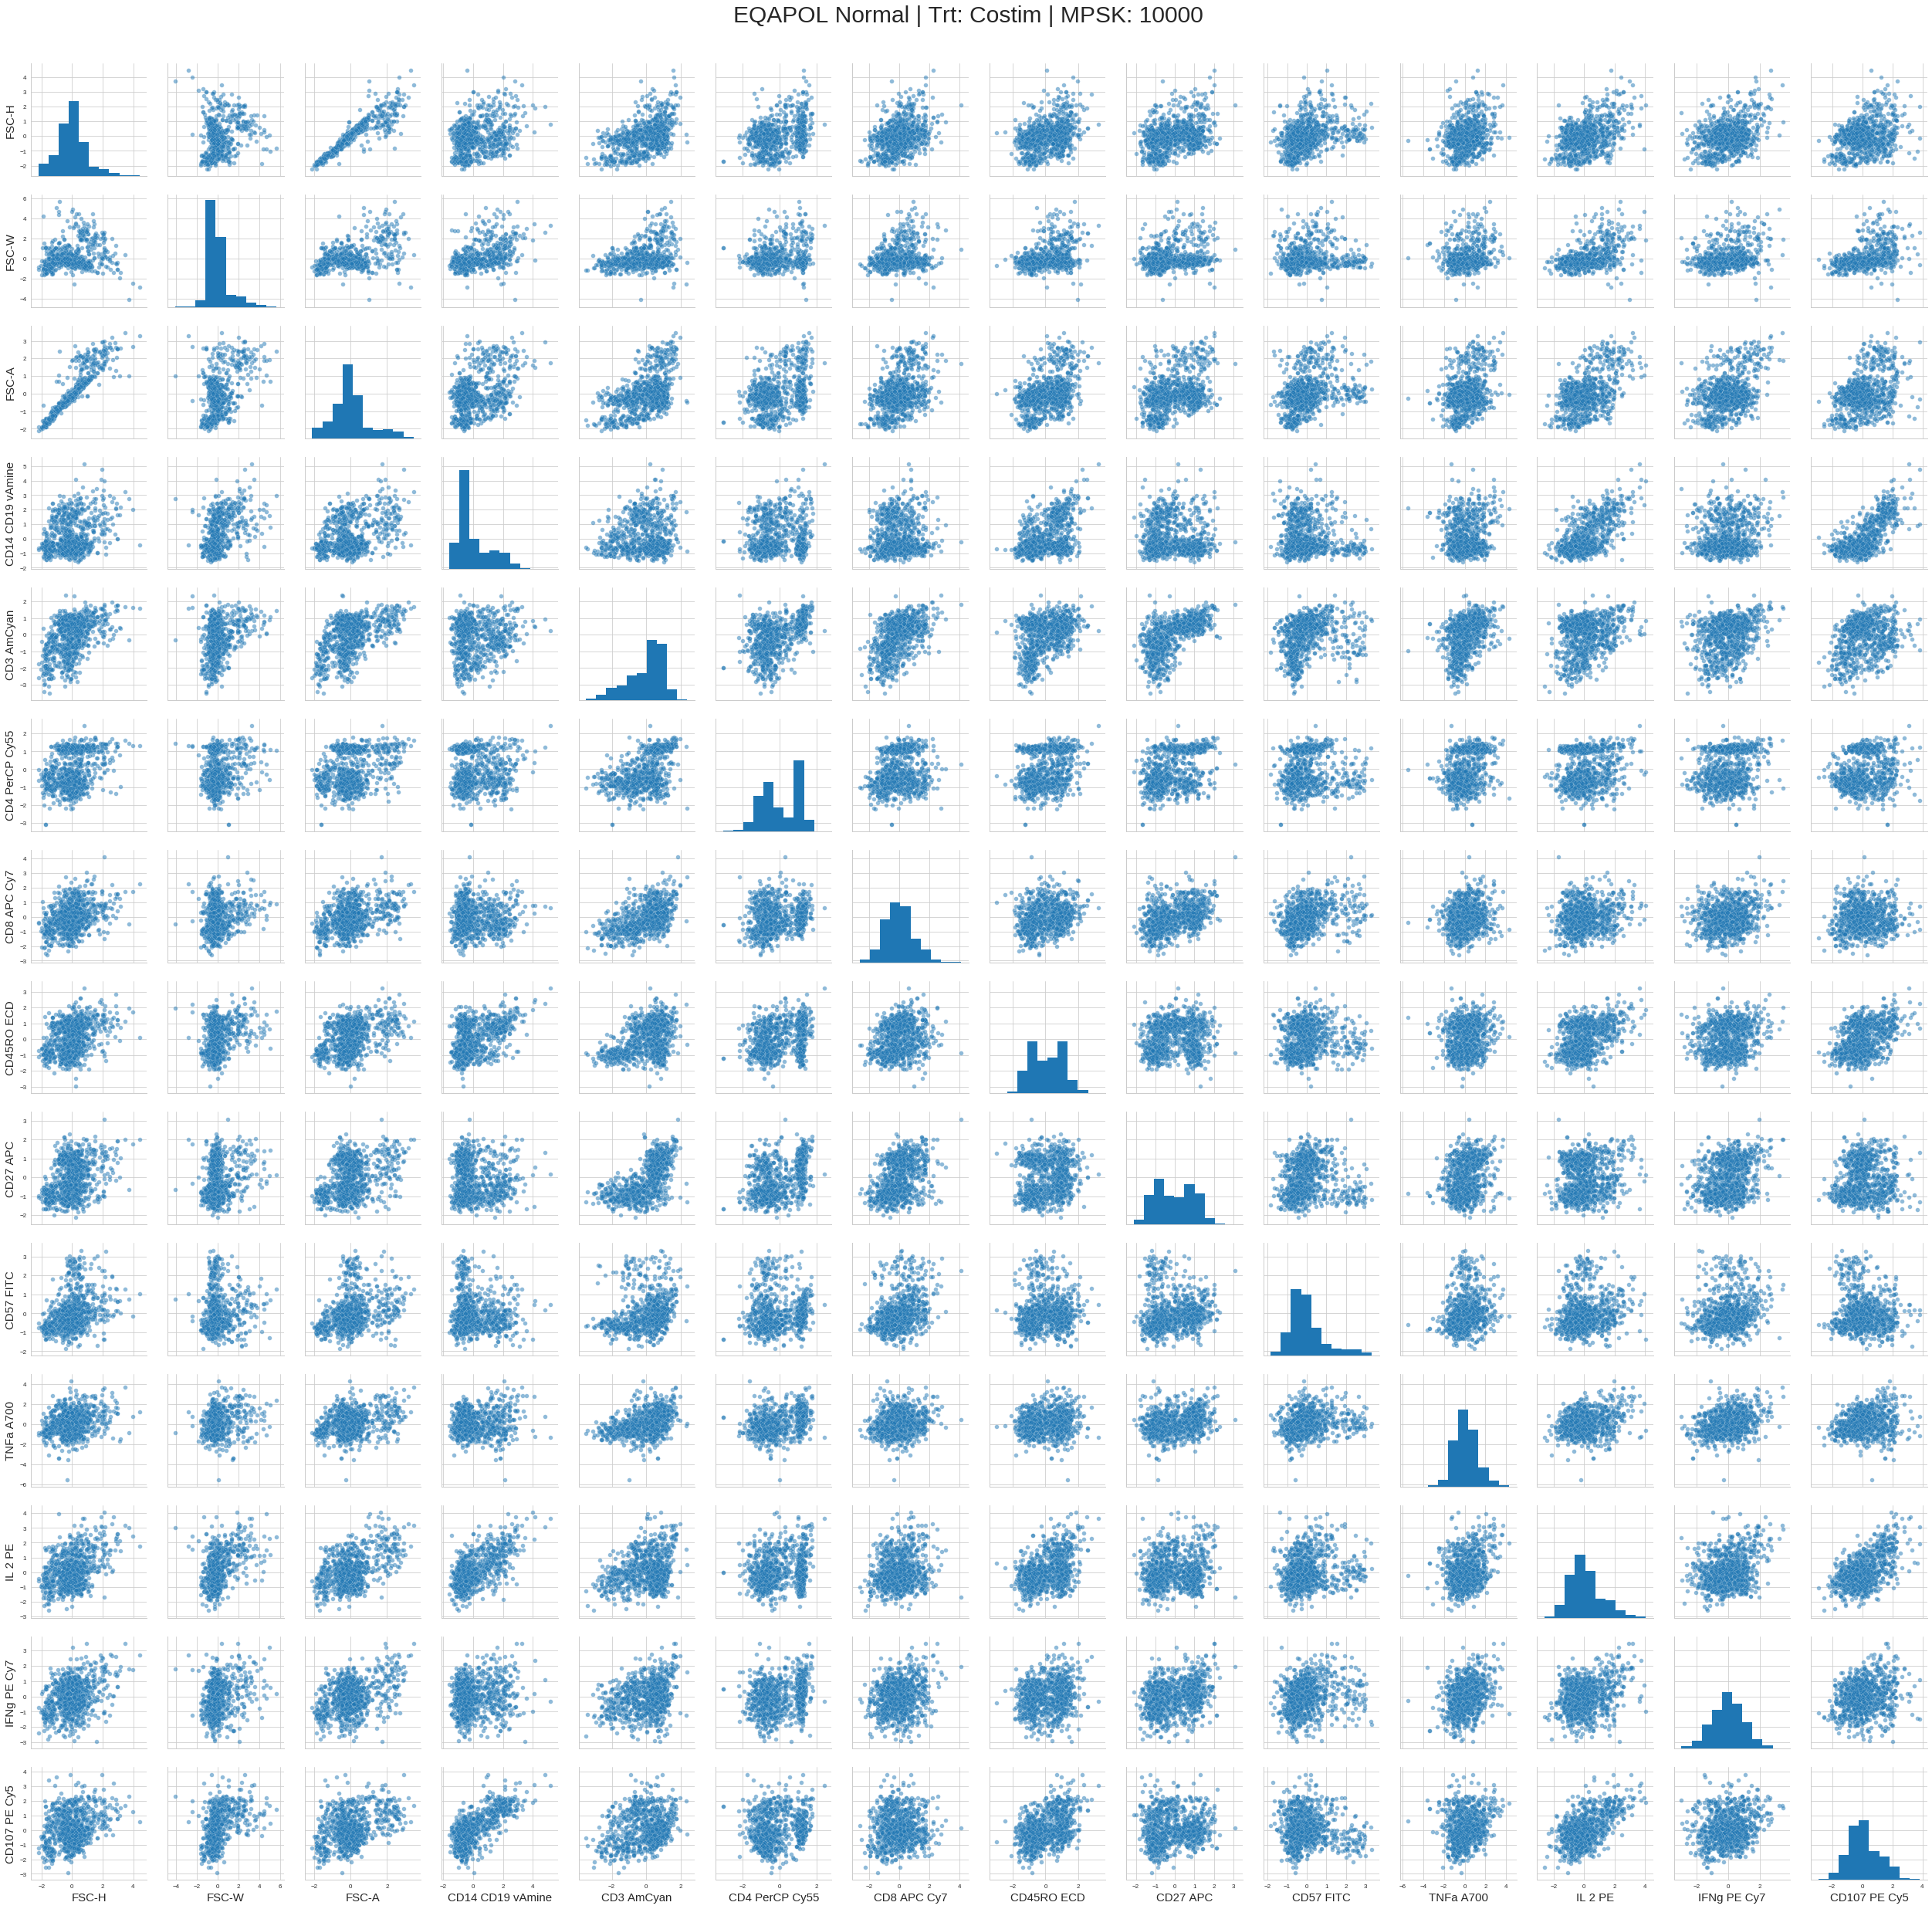

In [17]:
arr = matrix[0][:1000]
dat = pd.DataFrame(arr, columns=marker.Marker)

title = 'EQAPOL Normal | Trt: Costim | MPSK: 10000'
sns.set_context("paper", rc={"axes.labelsize":15}) 
plot = sns.pairplot(dat, plot_kws={"alpha": 0.5})

plt.subplots_adjust(top=0.95)
plot.fig.suptitle(title, size = 30)

# Store the results

In [18]:
!ls /data/clintko/flow_EQAPOL_normal/mpsk

C_1e4.csv		 mpsk_1e4_costim_chain.RDS  mpsk_1e4_simulation.P
mpsk_1e4_cmv_cal.RDS	 mpsk_1e4_costim_res.RDS    Y_1e4_cmv.csv
mpsk_1e4_cmv_chain.RDS	 mpsk_1e4_seb_cal.RDS	    Y_1e4_costim.csv
mpsk_1e4_cmv_res.RDS	 mpsk_1e4_seb_chain.RDS     Y_1e4_seb.csv
mpsk_1e4_costim_cal.RDS  mpsk_1e4_seb_res.RDS


In [19]:
DAT_DIR

'/data/clintko/flow_EQAPOL_normal/mpsk'

In [20]:
### set up a pickle file
fname = "wrap01_mpsk.P"
fpath = os.path.join(DAT_DIR, fname)
file = open(fpath, 'wb')

### store the dictionary
pickle.dump(wrap_data, file)
file.close()

In [21]:
!ls /data/clintko/flow_EQAPOL_normal/mpsk

C_1e4.csv		 mpsk_1e4_costim_chain.RDS  mpsk_1e4_simulation.P
mpsk_1e4_cmv_cal.RDS	 mpsk_1e4_costim_res.RDS    wrap01_mpsk.P
mpsk_1e4_cmv_chain.RDS	 mpsk_1e4_seb_cal.RDS	    Y_1e4_cmv.csv
mpsk_1e4_cmv_res.RDS	 mpsk_1e4_seb_chain.RDS     Y_1e4_costim.csv
mpsk_1e4_costim_cal.RDS  mpsk_1e4_seb_res.RDS	    Y_1e4_seb.csv
